# Microsoft BiomedCLIP — Pan-Medical Contrastive Vision-Language Model

This notebook evaluates `microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224` across all five week1 datasets covering radiology, pathology, and hyperspectral imaging.

**What is BiomedCLIP?**  
BiomedCLIP is a CLIP-style contrastive vision-language model trained on **15 million** biomedical image-text pairs from PubMed Central. Unlike domain-specific models (CONCH → histopathology only; MUSK → pathology only), BiomedCLIP is the most broadly trained publicly available medical contrastive model, covering radiology, pathology, microscopy, and clinical photography.

**Model specs:**
- Architecture: ViT-B/16 image encoder + PubMedBERT text encoder
- Input: 224×224 pixels
- Training: 15M biomedical figure–caption pairs (PMC open access)
- Access: Public, no gating required
- API: `open_clip` (same interface as CONCH)
- Paper: [Zhang et al., NEJM AI 2024](https://doi.org/10.1056/AIoa2300240)

## Model Comparison

| Aspect | BiomedCLIP | MUSK | CONCH |
|---|---|---|---|
| Model type | Contrastive (CLIP) | Contrastive (masked + contrastive) | Contrastive (CLIP) |
| Training data | 15M PMC figure–captions | 50M pathology images + 1B text tokens | 1.17M histopathology pairs |
| Domain | **Pan-medical** (radiology + pathology) | Pathology only | Histopathology only |
| Input size | 224×224 | 384×384 | 448×448 |
| API | `open_clip` | Custom `musk` package | Custom `conch` package |
| Access | Public | Gated (HF token) | Gated (HF token) |

## Tasks Per Sample
1. **Zero-shot classification** — rank modality-appropriate candidate labels by softmax similarity.
2. **Image–text similarity** — cosine similarity against the ground-truth caption (Quilt1M samples only).

## Dataset Overview

All five week1 datasets are appropriate for BiomedCLIP given its pan-medical training:

| # | Dataset | Modality | Samples | Zero-shot label source |
|---|---|---|---|---|
| 1 | IQ-OTH/NCCD | Chest CT | 3 (Benign/Malignant/Normal) | Lung cancer taxonomy |
| 2 | Spinal CT | Spectral CT | 1 (Myel_001 DICOM slice) | Vertebral pathology taxonomy |
| 3 | Quilt1M | H&E histopathology | 4 (pubmed/quilt/openpath/laion) | `quilt_1M_lookup.csv` pathology column |
| 4 | PKG HistologyHSI-GB | Hyperspectral → pseudo-RGB | 1 (P1 tumor ROI) | Brain tumor taxonomy |
| 5 | OASIS-1 | Brain MRI (T1) | 1 (mid-axial slice) | Neurological condition taxonomy |

In [1]:
import warnings
import logging

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("transformers").setLevel(logging.ERROR)

In [2]:
import ast
import json
import time
from pathlib import Path

import nibabel as nib
import numpy as np
import open_clip
import pandas as pd
import pydicom
import spectral.io.envi as envi
import torch
from PIL import Image

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

ModuleNotFoundError: No module named 'open_clip'

In [ ]:
# Load BiomedCLIP via open_clip — no token required (public model)
MODEL_HF = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"

_t0_load = time.perf_counter()
model, _, preprocess = open_clip.create_model_and_transforms(MODEL_HF)
tokenizer = open_clip.get_tokenizer(MODEL_HF)
model = model.to(device)
model.eval()
model_load_s = round(time.perf_counter() - _t0_load, 2)

print("BiomedCLIP loaded successfully.")
print("  Architecture : ViT-B/16 image encoder + PubMedBERT text encoder")
print("  Training data: 15M PMC biomedical figure-caption pairs")
print("  Input size   : 224×224")
print(f"  Device       : {device}")

BiomedCLIP loaded successfully.
  Architecture : ViT-B/16 image encoder + PubMedBERT text encoder
  Training data: 15M PMC biomedical figure-caption pairs
  Input size   : 224×224
  Device       : mps


## Modality-Appropriate Zero-shot Label Sets

Each dataset is paired with a clinically relevant label set and a prompt template appropriate for BiomedCLIP's PMC training distribution.

- **Chest CT**: lung cancer subtypes + benign/normal categories
- **Spinal CT**: vertebral pathologies relevant to multiple myeloma workup
- **Quilt1M**: unique pathology sub-specialties parsed from `quilt_1M_lookup.csv` (same as CONCH notebook)
- **PKG HistologyHSI-GB**: brain tumor classification categories
- **OASIS-1**: neurological conditions relevant to dementia evaluation

In [ ]:
# ── Per-modality label sets ──────────────────────────────────────────────────
CHEST_CT_LABELS = [
    "benign lung nodule",
    "malignant lung mass",
    "normal lung parenchyma",
    "pulmonary adenocarcinoma",
    "squamous cell carcinoma of the lung",
    "small cell lung carcinoma",
    "lung metastasis",
    "consolidation",
    "emphysema",
    "pulmonary fibrosis",
]

SPINAL_CT_LABELS = [
    "normal vertebral body",
    "vertebral lytic lesion",
    "vertebral compression fracture",
    "multiple myeloma spine",
    "spinal metastasis",
    "disc herniation",
    "spinal canal stenosis",
    "vertebral sclerotic lesion",
    "plasmacytoma",
]

BRAIN_PATHOLOGY_LABELS = [
    "glioblastoma multiforme",
    "normal brain tissue",
    "low-grade glioma",
    "meningioma",
    "brain metastasis",
    "astrocytoma",
    "oligodendroglioma",
    "necrotic tumor tissue",
    "tumor infiltrating lymphocytes",
]

BRAIN_MRI_LABELS = [
    "normal brain MRI",
    "Alzheimer's disease",
    "mild cognitive impairment",
    "cortical atrophy",
    "vascular dementia",
    "age-related brain changes",
    "frontotemporal dementia",
    "white matter hyperintensities",
    "hippocampal atrophy",
]

# ── Per-modality prompt templates ────────────────────────────────────────────
TEMPLATES = {
    "chest_ct":        "a chest CT image showing {}",
    "spinal_ct":       "a spinal CT image showing {}",
    "pathology_he":    "an H&E stained histopathology image of {}",
    "brain_pathology": "a brain histopathology image showing {}",
    "brain_mri":       "a brain MRI scan showing {}",
}

# ── Quilt1M CSV categories ───────────────────────────────────────────────────
CSV_PATH = Path("../week1/data/quilt_1M_lookup.csv")
df_quilt = pd.read_csv(CSV_PATH, low_memory=False)

def parse_pathology_list(val) -> list[str]:
    if pd.isna(val) or str(val).strip() in ("", "nan", "[]"):
        return []
    try:
        parsed = ast.literal_eval(str(val))
        return [s.strip() for s in parsed if isinstance(s, str) and s.strip()]
    except (ValueError, SyntaxError):
        return []

QUILT_CATEGORIES = sorted(set(
    cat
    for cats in df_quilt["pathology"].apply(parse_pathology_list)
    for cat in cats
))

print(f"Chest CT labels    : {len(CHEST_CT_LABELS)}")
print(f"Spinal CT labels   : {len(SPINAL_CT_LABELS)}")
print(f"Brain pathol labels: {len(BRAIN_PATHOLOGY_LABELS)}")
print(f"Brain MRI labels   : {len(BRAIN_MRI_LABELS)}")
print(f"Quilt1M categories : {len(QUILT_CATEGORIES)} (from CSV)")
print("\nQuilt1M categories:", QUILT_CATEGORIES)

Chest CT labels    : 10
Spinal CT labels   : 9
Brain pathol labels: 9
Brain MRI labels   : 9
Quilt1M categories : 18 (from CSV)

Quilt1M categories: ['Bone', 'Breast', 'Cardiac', 'Cytopathology', 'Dermatopathology', 'Endocrine', 'Gastrointestinal', 'Genitourinary', 'Gynecologic', 'Head and Neck', 'Hematopathology', 'Neuropathology', 'Ophthalmic', 'Others', 'Pediatric', 'Pulmonary', 'Renal', 'Soft tissue']


In [ ]:
def load_image(path: Path) -> Image.Image:
    return Image.open(path).convert("RGB")

def load_dicom(path: Path) -> Image.Image:
    ds = pydicom.dcmread(str(path))
    raw = ds.pixel_array.astype(float)
    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    hu = raw * slope + intercept
    wl, ww = 40.0, 400.0
    lo, hi = wl - ww / 2, wl + ww / 2
    normalised = ((np.clip(hu, lo, hi) - lo) / (hi - lo) * 255).astype(np.uint8)
    return Image.fromarray(normalised).convert("RGB")

def load_hsi_pseudo_rgb(hdr_path: Path) -> Image.Image:
    img = envi.open(str(hdr_path))
    wavelengths = np.array([float(w) for w in img.metadata["wavelength"]])
    cube = img.load()
    def norm(arr): return ((arr - arr.min()) / (arr.max() - arr.min() + 1e-9) * 255).astype(np.uint8)
    rgb = np.stack([norm(np.squeeze(cube[:, :, int(np.argmin(np.abs(wavelengths - t)))])) for t in [650, 550, 450]], axis=2)
    return Image.fromarray(rgb)

def load_nifti_slice(img_path: Path) -> Image.Image:
    vol = np.squeeze(nib.load(str(img_path)).get_fdata())
    slc = np.rot90(vol[:, :, vol.shape[2] // 2])
    normalised = ((slc - slc.min()) / (slc.max() - slc.min() + 1e-9) * 255).astype(np.uint8)
    return Image.fromarray(normalised).convert("RGB")

LOADER_MAP = {"image": load_image, "dicom": load_dicom, "hsi": load_hsi_pseudo_rgb, "nifti": load_nifti_slice}
print("Loaders ready:", list(LOADER_MAP.keys()))

Loaders ready: ['image', 'dicom', 'hsi', 'nifti']


In [ ]:
def encode_image(pil_img: Image.Image) -> torch.Tensor:
    """Return normalised image embedding of shape (1, D)."""
    tensor = preprocess(pil_img.convert("RGB")).unsqueeze(0).to(device)
    with torch.inference_mode():
        return model.encode_image(tensor, normalize=True)

def encode_texts(texts: list[str]) -> torch.Tensor:
    """Return normalised text embeddings of shape (N, D)."""
    tokens = tokenizer(texts).to(device)
    with torch.inference_mode():
        return model.encode_text(tokens, normalize=True)

def zero_shot_classify(image_emb: torch.Tensor, labels: list[str], template: str, top_k: int = 5) -> list[tuple[str, float]]:
    """Rank labels by softmax-scaled cosine similarity using the given prompt template."""
    prompts = [template.format(l) for l in labels]
    text_embs = encode_texts(prompts)
    probs = (100.0 * image_emb @ text_embs.T).softmax(dim=-1)[0].cpu().numpy()
    return sorted(zip(labels, probs.tolist()), key=lambda x: x[1], reverse=True)[:top_k]

def image_text_similarity(image_emb: torch.Tensor, caption: str) -> float:
    """Cosine similarity between image and a single caption (both L2-normalised)."""
    cap_emb = encode_texts([caption])
    return round((image_emb * cap_emb).sum().item(), 4)

print("Helpers defined.")

Helpers defined.


## Dataset 1: IQ-OTH/NCCD — Lung Cancer Chest CT
Three 2D JPEG slices from a chest CT series (Benign, Malignant, Normal). BiomedCLIP is evaluated against 10 lung cancer / pulmonary condition labels. Expected: the Malignant slice should score higher on adenocarcinoma / malignant mass labels; Normal should score highest on normal parenchyma.

## Dataset 2: Spinal CT (DICOM) — Multiple Myeloma
Single DICOM slice from the Myel_001 spectral CT series (MonoE 80 keV). DICOM pixel values are converted to Hounsfield Units and soft-tissue windowed (W=400, L=40) before encoding. Labels focus on vertebral body pathologies relevant to myeloma staging.

## Dataset 3: Quilt1M — H&E Histopathology (4 subsets)
One H&E image per Quilt1M source (pubmed, quilt/YouTube, openpath/Twitter, laion). Labels are all unique pathology sub-specialties extracted from the `pathology` column of `quilt_1M_lookup.csv`. Image–caption cosine similarity is also reported for each sample using the ground-truth CSV caption.

## Dataset 4: PKG HistologyHSI-GB — Glioblastoma Hyperspectral
Hyperspectral cube (ENVI BIL) converted to pseudo-RGB by selecting bands at 650/550/450 nm. Labels are brain tumor classification categories. Note: BiomedCLIP has not been explicitly trained on HSI data; this tests whether the pseudo-RGB approximation preserves enough visual information for meaningful classification.

## Dataset 5: OASIS-1 — Brain MRI (T1)
Mid-axial slice of the T88 atlas-registered, bias-field-corrected T1 volume from OAS1_0001_MR1 (74-year-old female, CDR=0, non-demented). Labels cover the full spectrum of dementia-related diagnoses and normal aging, testing BiomedCLIP's ability to interpret structural MRI.

In [ ]:
BASE = Path("../week1/data")

def get_quilt_caption(filename: str) -> str:
    matches = df_quilt[df_quilt["image_path"] == filename]
    if matches.empty: return ""
    cap = matches.iloc[0]["caption"]
    return "" if pd.isna(cap) else str(cap)

LOCAL_SAMPLES = [
    {"name": "IQ-OTH/NCCD — Benign",            "path": BASE/"IQ-OTH_NCCD/Benign/Benign_case_1.jpg",       "type": "image",  "labels": CHEST_CT_LABELS,      "template": TEMPLATES["chest_ct"],        "caption_file": None},
    {"name": "IQ-OTH/NCCD — Malignant",          "path": BASE/"IQ-OTH_NCCD/Malignant/Malignant_case_1.jpg", "type": "image",  "labels": CHEST_CT_LABELS,      "template": TEMPLATES["chest_ct"],        "caption_file": None},
    {"name": "IQ-OTH/NCCD — Normal",             "path": BASE/"IQ-OTH_NCCD/Normal/Normal_case_1.jpg",       "type": "image",  "labels": CHEST_CT_LABELS,      "template": TEMPLATES["chest_ct"],        "caption_file": None},
    {"name": "Spinal CT — Myel_001 (DICOM)",     "path": BASE/"Spinal_DICOM/Myel_001/MonoE_80keVHU/1-0001.dcm", "type": "dicom", "labels": SPINAL_CT_LABELS,   "template": TEMPLATES["spinal_ct"],       "caption_file": None},
    {"name": "Quilt1M — PubMed",                 "path": BASE/"Quilt1M_pubmed/c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg", "type": "image", "labels": QUILT_CATEGORIES, "template": TEMPLATES["pathology_he"], "caption_file": "c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg"},
    {"name": "Quilt1M — YouTube (quilt)",        "path": BASE/"Quilt1M_quilt/dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg", "type": "image", "labels": QUILT_CATEGORIES, "template": TEMPLATES["pathology_he"], "caption_file": "dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg"},
    {"name": "Quilt1M — OpenPath (Twitter)",     "path": BASE/"Quilt1M_openpath/994701482116173824_0.jpg",     "type": "image", "labels": QUILT_CATEGORIES, "template": TEMPLATES["pathology_he"], "caption_file": "994701482116173824_0.jpg"},
    {"name": "Quilt1M — LAION",                  "path": BASE/"Quilt1M_laion/00004000040081.jpg",               "type": "image", "labels": QUILT_CATEGORIES, "template": TEMPLATES["pathology_he"], "caption_file": "00004000040081.jpg"},
    {"name": "PKG HistologyHSI-GB — P1 Tumor",  "path": BASE/"PKG_HistologyHSI_GB/P1/ROI_01_C01_T/raw.hdr",   "type": "hsi",   "labels": BRAIN_PATHOLOGY_LABELS, "template": TEMPLATES["brain_pathology"], "caption_file": None},
    {"name": "OASIS-1 Brain MRI — OAS1_0001",   "path": BASE/"Oasis1/OAS1_0001_MR1/PROCESSED/MPRAGE/T88_111/OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.img", "type": "nifti", "labels": BRAIN_MRI_LABELS, "template": TEMPLATES["brain_mri"], "caption_file": None},
]

print(f"Defined {len(LOCAL_SAMPLES)} samples.")
for s in LOCAL_SAMPLES:
    print(f"  [{'OK' if Path(s['path']).exists() else 'MISSING'}] {s['name']}")

Defined 10 samples.
  [OK] IQ-OTH/NCCD — Benign
  [OK] IQ-OTH/NCCD — Malignant
  [OK] IQ-OTH/NCCD — Normal
  [OK] Spinal CT — Myel_001 (DICOM)
  [OK] Quilt1M — PubMed
  [OK] Quilt1M — YouTube (quilt)
  [OK] Quilt1M — OpenPath (Twitter)
  [OK] Quilt1M — LAION
  [OK] PKG HistologyHSI-GB — P1 Tumor
  [OK] OASIS-1 Brain MRI — OAS1_0001



  IQ-OTH/NCCD — Benign
  [TASK 1] Zero-shot classification (top-5):
    1. normal lung parenchyma                   66.02%
    2. lung metastasis                          11.68%
    3. consolidation                             5.77%
    4. pulmonary adenocarcinoma                  5.56%
    5. pulmonary fibrosis                        3.36%
  [TASK 2] No ground-truth caption — skipped


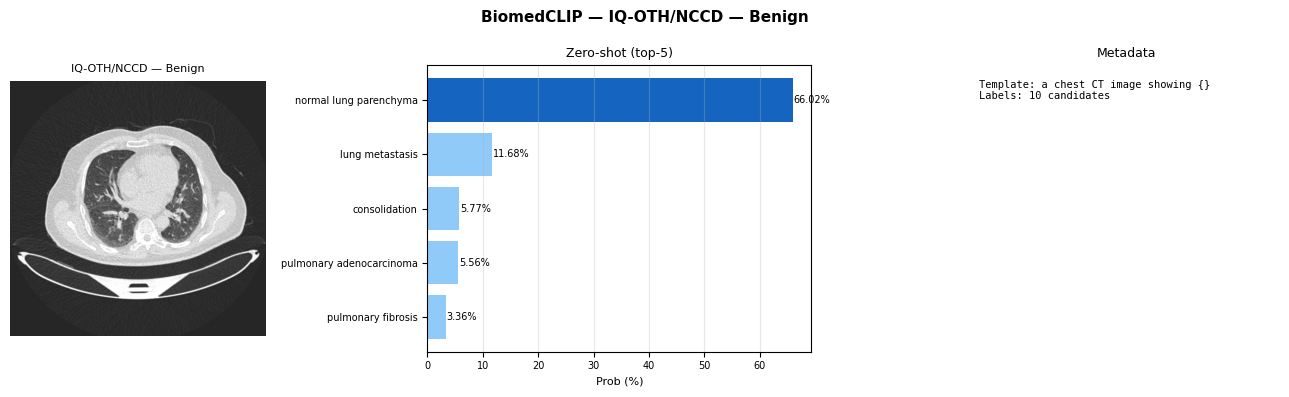

  [0.17s]

  IQ-OTH/NCCD — Malignant
  [TASK 1] Zero-shot classification (top-5):
    1. pulmonary fibrosis                       34.93%
    2. malignant lung mass                      28.10%
    3. lung metastasis                          21.60%
    4. pulmonary adenocarcinoma                  6.83%
    5. squamous cell carcinoma of the lung       4.11%
  [TASK 2] No ground-truth caption — skipped


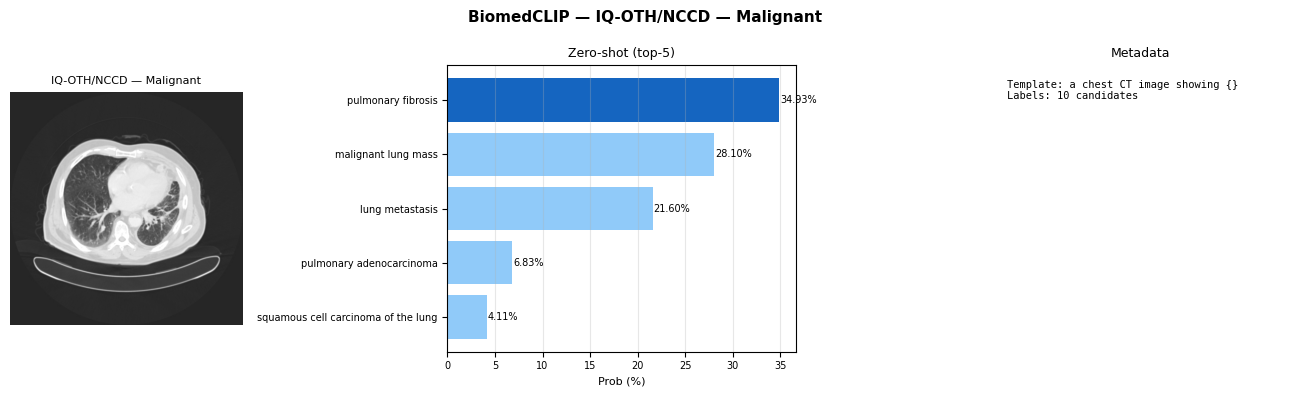

  [0.14s]

  IQ-OTH/NCCD — Normal
  [TASK 1] Zero-shot classification (top-5):
    1. normal lung parenchyma                   93.13%
    2. emphysema                                 6.14%
    3. benign lung nodule                        0.38%
    4. pulmonary fibrosis                        0.22%
    5. pulmonary adenocarcinoma                  0.05%
  [TASK 2] No ground-truth caption — skipped


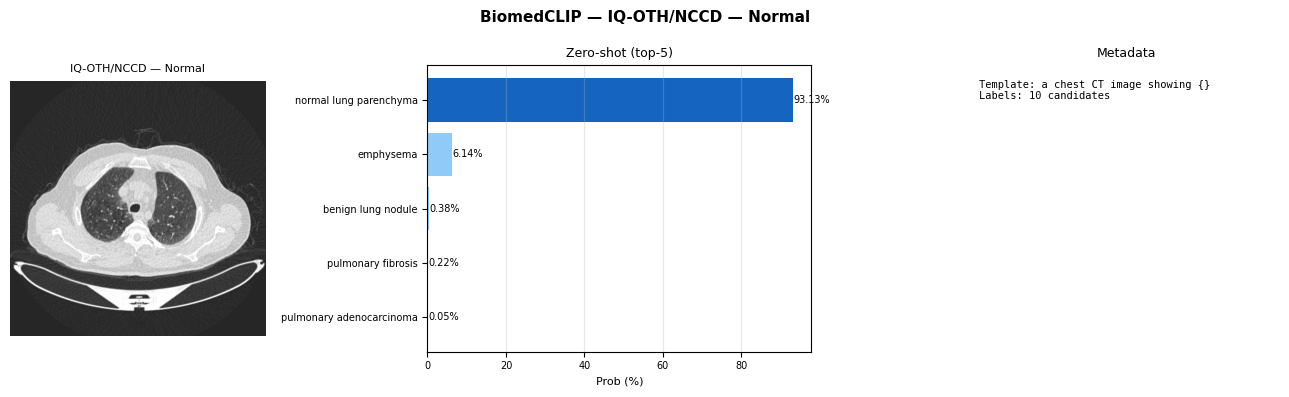

  [0.27s]

  Spinal CT — Myel_001 (DICOM)
  [TASK 1] Zero-shot classification (top-5):
    1. plasmacytoma                             97.92%
    2. spinal metastasis                         1.36%
    3. vertebral lytic lesion                    0.30%
    4. vertebral compression fracture            0.21%
    5. normal vertebral body                     0.09%
  [TASK 2] No ground-truth caption — skipped


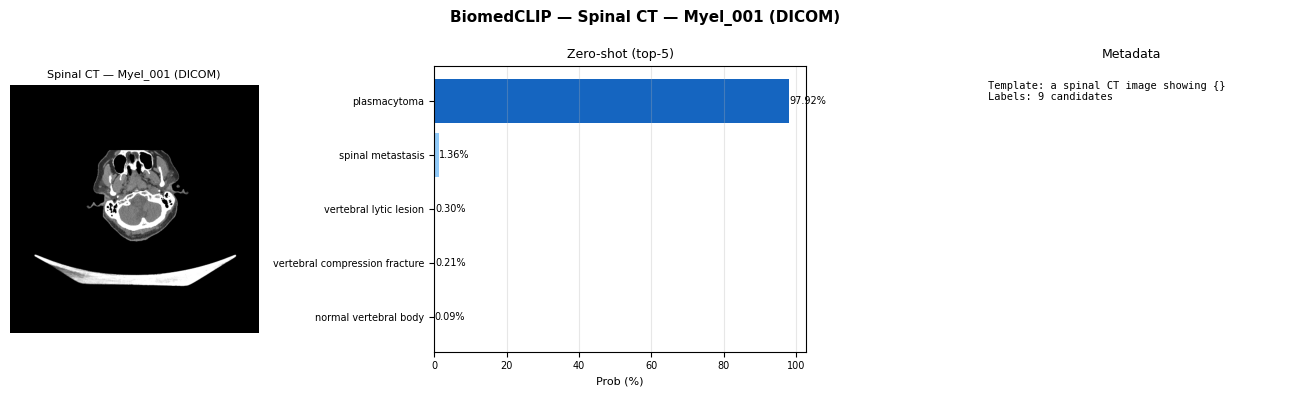

  [0.12s]

  Quilt1M — PubMed
  [TASK 1] Zero-shot classification (top-5):
    1. Bone                                     41.50%
    2. Cytopathology                            23.57%
    3. Breast                                   21.12%
    4. Head and Neck                            10.47%
    5. Pulmonary                                 1.83%
  [TASK 2] Image–caption similarity: 0.2957
           Caption: "The immunocytochemistry of IDH1 in MG63 and U2OS. IDH1 is specifically detected in the cytoplasm of "


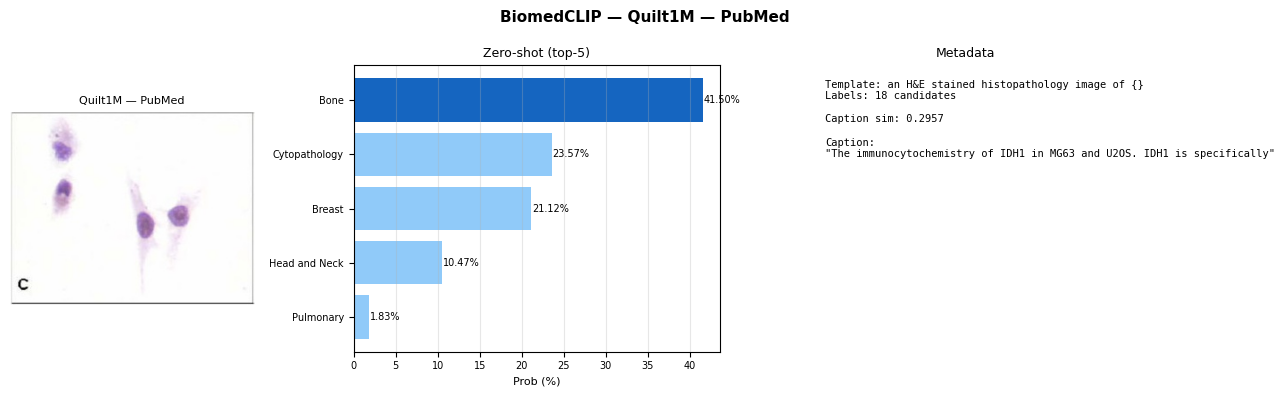

  [0.17s]

  Quilt1M — YouTube (quilt)
  [TASK 1] Zero-shot classification (top-5):
    1. Dermatopathology                         99.97%
    2. Hematopathology                           0.02%
    3. Breast                                    0.00%
    4. Head and Neck                             0.00%
    5. Soft tissue                               0.00%
  [TASK 2] Image–caption similarity: 0.2130
           Caption: "Nephrogenic systemic fibrosis is a fibrotic disorder with deep involvement that goes down to the fas"


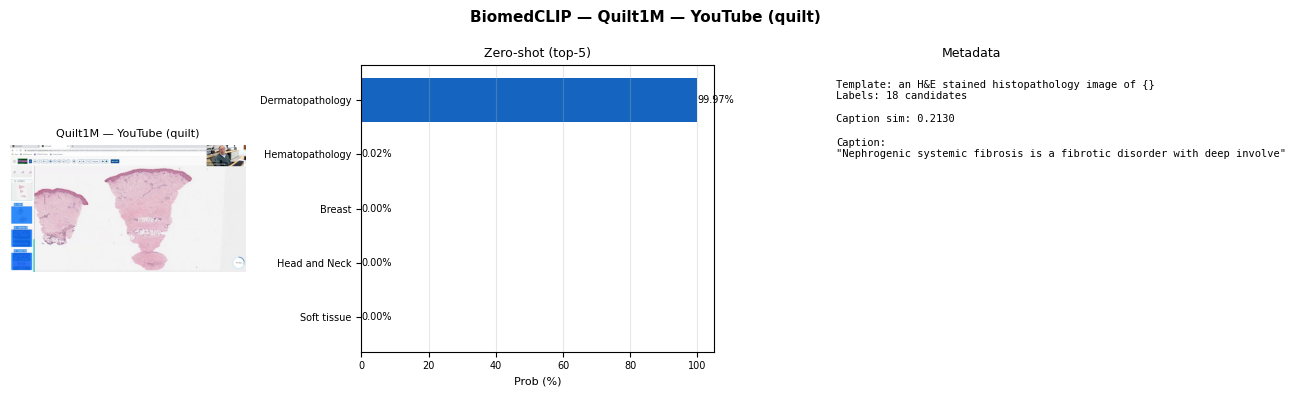

  [0.2s]

  Quilt1M — OpenPath (Twitter)
  [TASK 1] Zero-shot classification (top-5):
    1. Soft tissue                              87.65%
    2. Dermatopathology                          7.23%
    3. Others                                    3.13%
    4. Gastrointestinal                          0.85%
    5. Gynecologic                               0.59%
  [TASK 2] Image–caption similarity: 0.3308
           Caption: "Peritoneum, Day 4 These two biopsies (1 & 2) were taken from the same patient. What is your DailyDx "


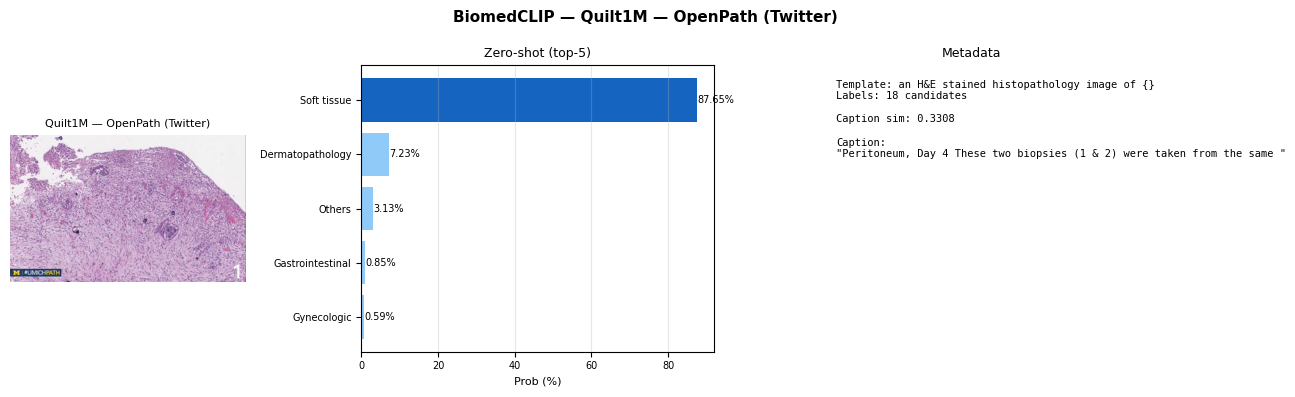

  [0.17s]

  Quilt1M — LAION
  [TASK 1] Zero-shot classification (top-5):
    1. Ophthalmic                               27.74%
    2. Genitourinary                            22.72%
    3. Bone                                     13.27%
    4. Gastrointestinal                         10.49%
    5. Breast                                    9.04%
  [TASK 2] Image–caption similarity: 0.2368
           Caption: "Cytosolic Sulfotransferase 1A1 /SULT1A1 Antibody"


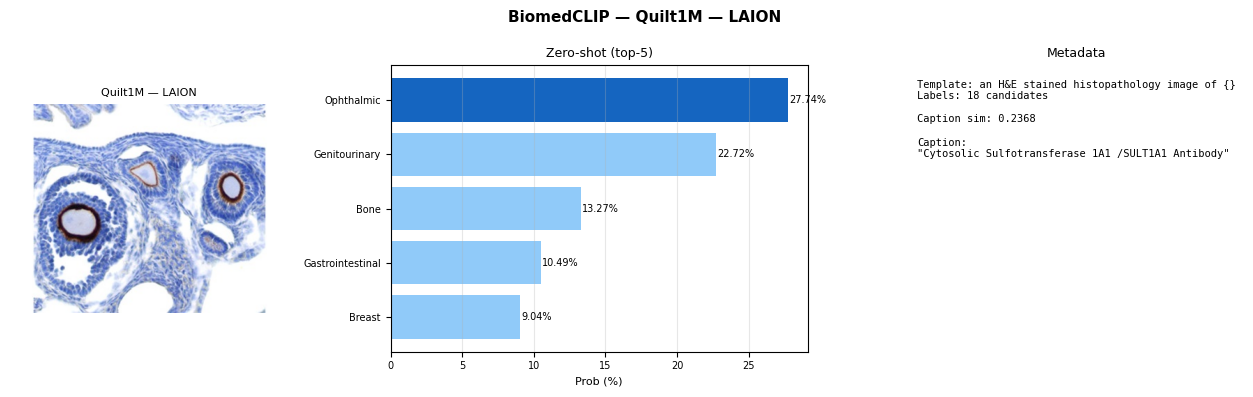

  [0.17s]

  PKG HistologyHSI-GB — P1 Tumor
  [TASK 1] Zero-shot classification (top-5):
    1. necrotic tumor tissue                    57.49%
    2. low-grade glioma                         34.38%
    3. brain metastasis                          4.77%
    4. astrocytoma                               2.73%
    5. oligodendroglioma                         0.33%
  [TASK 2] No ground-truth caption — skipped


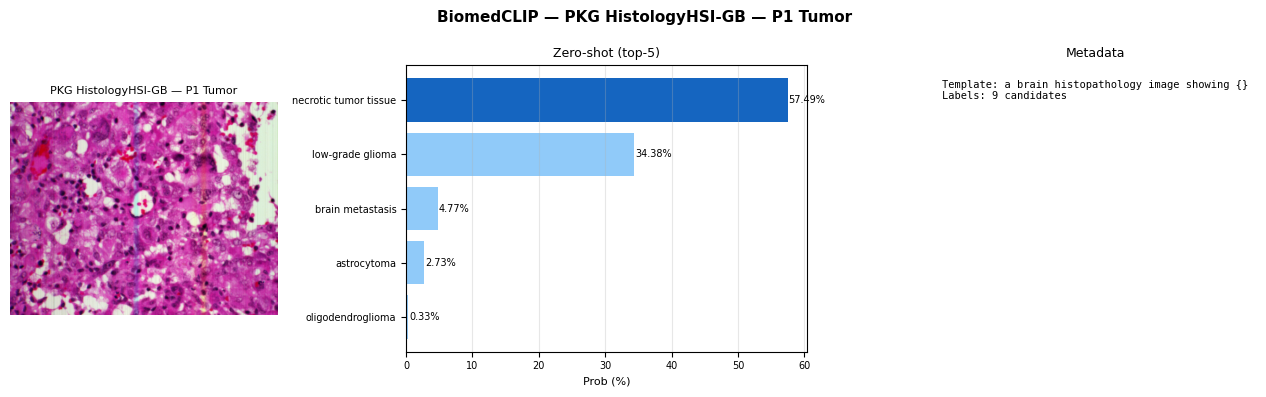

  [2.52s]

  OASIS-1 Brain MRI — OAS1_0001
  [TASK 1] Zero-shot classification (top-5):
    1. cortical atrophy                         92.69%
    2. mild cognitive impairment                 2.79%
    3. normal brain MRI                          2.38%
    4. Alzheimer's disease                       1.38%
    5. age-related brain changes                 0.64%
  [TASK 2] No ground-truth caption — skipped


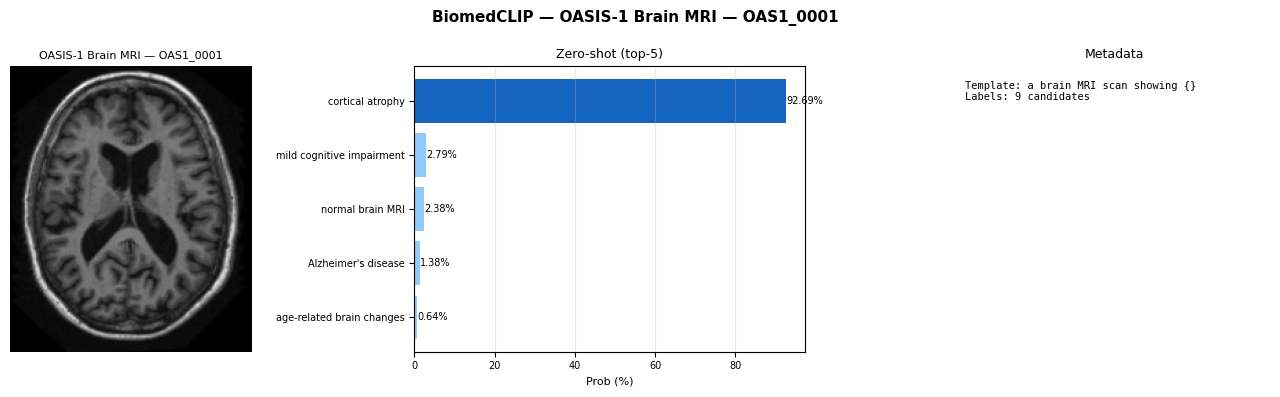

  [0.2s]

Total inference time: 4.12s  |  Model load: 6.03s
Results saved to biomedclip_results.json


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

RESULTS = []
_t_run_start = time.perf_counter()

for sample in LOCAL_SAMPLES:
    img_path = Path(sample["path"])
    print(f"\n{'='*65}")
    print(f"  {sample['name']}")
    if not img_path.exists():
        print(f"  [ERROR] Not found: {img_path}")
        continue

    _t0 = time.perf_counter()
    pil_img = LOADER_MAP[sample["type"]](img_path)
    image_emb = encode_image(pil_img)

    # Task 1: zero-shot classification
    top5 = zero_shot_classify(image_emb, sample["labels"], sample["template"])
    print("  [TASK 1] Zero-shot classification (top-5):")
    for rank, (label, prob) in enumerate(top5, 1):
        print(f"    {rank}. {label:<40} {prob*100:5.2f}%")

    # Task 2: image-text similarity (Quilt1M only)
    similarity = None
    caption = get_quilt_caption(sample["caption_file"]) if sample["caption_file"] else ""
    if caption:
        similarity = image_text_similarity(image_emb, caption)
        print(f"  [TASK 2] Image–caption similarity: {similarity:.4f}")
        print(f"           Caption: \"{caption[:100]}\"")
    else:
        print("  [TASK 2] No ground-truth caption — skipped")

    # Visualisation
    fig = plt.figure(figsize=(13, 4))
    gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1.5, 1.2])

    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(pil_img); ax_img.set_title(sample["name"], fontsize=8); ax_img.axis("off")

    ax_bar = fig.add_subplot(gs[1])
    lbls = [t[0] for t in top5]; probs = [t[1]*100 for t in top5]
    ax_bar.barh(lbls[::-1], probs[::-1], color=["#1565C0" if i==0 else "#90CAF9" for i in range(5)][::-1])
    ax_bar.set_xlabel("Prob (%)", fontsize=8); ax_bar.set_title("Zero-shot (top-5)", fontsize=9)
    ax_bar.tick_params(labelsize=7); ax_bar.grid(axis="x", alpha=0.3)
    for bar, p in zip(ax_bar.patches, probs[::-1]):
        ax_bar.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, f"{p:.2f}%", va="center", fontsize=7)

    ax_meta = fig.add_subplot(gs[2]); ax_meta.axis("off")
    meta_lines = [f"Template: {sample['template'][:45]}", f"Labels: {len(sample['labels'])} candidates", ""]
    if caption:
        meta_lines += [f"Caption sim: {similarity:.4f}", "", f"Caption:", f"\"{caption[:70]}\""]
    ax_meta.text(0.02, 0.95, "\n".join(meta_lines), transform=ax_meta.transAxes,
                 fontsize=7.5, va="top", family="monospace")
    ax_meta.set_title("Metadata", fontsize=9)

    fig.suptitle(f"BiomedCLIP — {sample['name']}", fontsize=11, fontweight="bold")
    plt.tight_layout(); plt.show()

    sample_time_s = round(time.perf_counter() - _t0, 2)
    print(f"  [{sample_time_s}s]")
    RESULTS.append({"sample": sample["name"], "top1": top5[0][0], "top1_pct": round(top5[0][1]*100,2),
                    "top2": top5[1][0], "top2_pct": round(top5[1][1]*100,2), "similarity": similarity,
                    "time_s": sample_time_s, "model_load_s": model_load_s})
total_inference_s = round(time.perf_counter() - _t_run_start, 2)
print(f"\nTotal inference time: {total_inference_s}s  |  Model load: {model_load_s}s")

BIOMEDCLIP_RESULTS_PATH = Path("biomedclip_results.json")
with open(BIOMEDCLIP_RESULTS_PATH, "w") as _f:
    json.dump({"model_load_s": model_load_s, "total_inference_s": total_inference_s, "results": RESULTS}, _f, indent=2)
print(f"Results saved to {BIOMEDCLIP_RESULTS_PATH}")


In [ ]:
import pandas as pd
df = pd.DataFrame(RESULTS)
print("BiomedCLIP Evaluation Summary")
print("="*85)
print(f"{'Sample':<42} {'Top-1':<30} {'Prob%':>5}  {'Cap.Sim':>7}")
print("-"*85)
for _, r in df.iterrows():
    sim = f"{r['similarity']:.4f}" if r["similarity"] is not None else "  N/A "
    print(f"{r['sample']:<42} {r['top1']:<30} {r['top1_pct']:>5.2f}%  {sim:>7}")
print("="*85)
sims = df["similarity"].dropna()
if not sims.empty:
    print(f"Mean image–caption similarity (Quilt1M): {sims.mean():.4f}")

BiomedCLIP Evaluation Summary
Sample                                     Top-1                          Prob%  Cap.Sim
-------------------------------------------------------------------------------------
IQ-OTH/NCCD — Benign                       normal lung parenchyma         66.02%      nan
IQ-OTH/NCCD — Malignant                    pulmonary fibrosis             34.93%      nan
IQ-OTH/NCCD — Normal                       normal lung parenchyma         93.13%      nan
Spinal CT — Myel_001 (DICOM)               plasmacytoma                   97.92%      nan
Quilt1M — PubMed                           Bone                           41.50%   0.2957
Quilt1M — YouTube (quilt)                  Dermatopathology               99.97%   0.2130
Quilt1M — OpenPath (Twitter)               Soft tissue                    87.65%   0.3308
Quilt1M — LAION                            Ophthalmic                     27.74%   0.2368
PKG HistologyHSI-GB — P1 Tumor             necrotic tumor tissue          5